In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from src.Utils import plot_all_models_for_variable
from tensorflow.keras.models import load_model
import joblib

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [4]:
normalizer_x = MinMaxScaler(feature_range=(0, 1))
x_train_norm = normalizer_x.fit_transform(x_train)
x_test_norm = normalizer_x.transform(x_test)
y_train_qgen = y_train[['QGEN7']]
y_train_perd = y_train[['PERD']]
y_train_volt = y_train.drop(columns=['QGEN7', 'PERD'])
normalizer_qgen = MinMaxScaler(feature_range=(0, 1))
normalizer_volts = MinMaxScaler(feature_range=(0, 1))
normalizer_perd = MinMaxScaler(feature_range=(0, 1))
y_train_qgen_norm = normalizer_qgen.fit_transform(y_train_qgen)
y_train_perd_norm = normalizer_perd.fit_transform(y_train_perd)
y_train_volt_norm = normalizer_volts.fit_transform(y_train_volt)

In [5]:
esr_xgb_model = joblib.load('../models/ESR_MO_XGBoost.pkl')
esr_rf_model = joblib.load('../models/ESR_MO_RandomForest.pkl')
xgb_model = joblib.load('../models/MO_XGBoost.pkl')
rf_model = joblib.load('../models/MO_RandomForest.pkl')
nn_model = load_model('../models/MO_NeuralNetwork.keras')

In [6]:
esr_xgb_predictions = esr_xgb_model.predict(x_test)
esr_rf_predictions = esr_rf_model.predict(x_test)
xgb_predictions = xgb_model.predict(x_test)
rf_predictions = rf_model.predict(x_test)

In [7]:
nn_predictions_norm = nn_model.predict(x_test_norm)
y_pred_volts = normalizer_volts.inverse_transform(nn_predictions_norm[0])
y_pred_perd = normalizer_perd.inverse_transform(nn_predictions_norm[1])
y_pred_qgen = normalizer_qgen.inverse_transform(nn_predictions_norm[2])
nn_predictions = pd.DataFrame(np.hstack([y_pred_volts, y_pred_perd, y_pred_qgen]), columns=y_test.columns, index=y_test.index)

656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


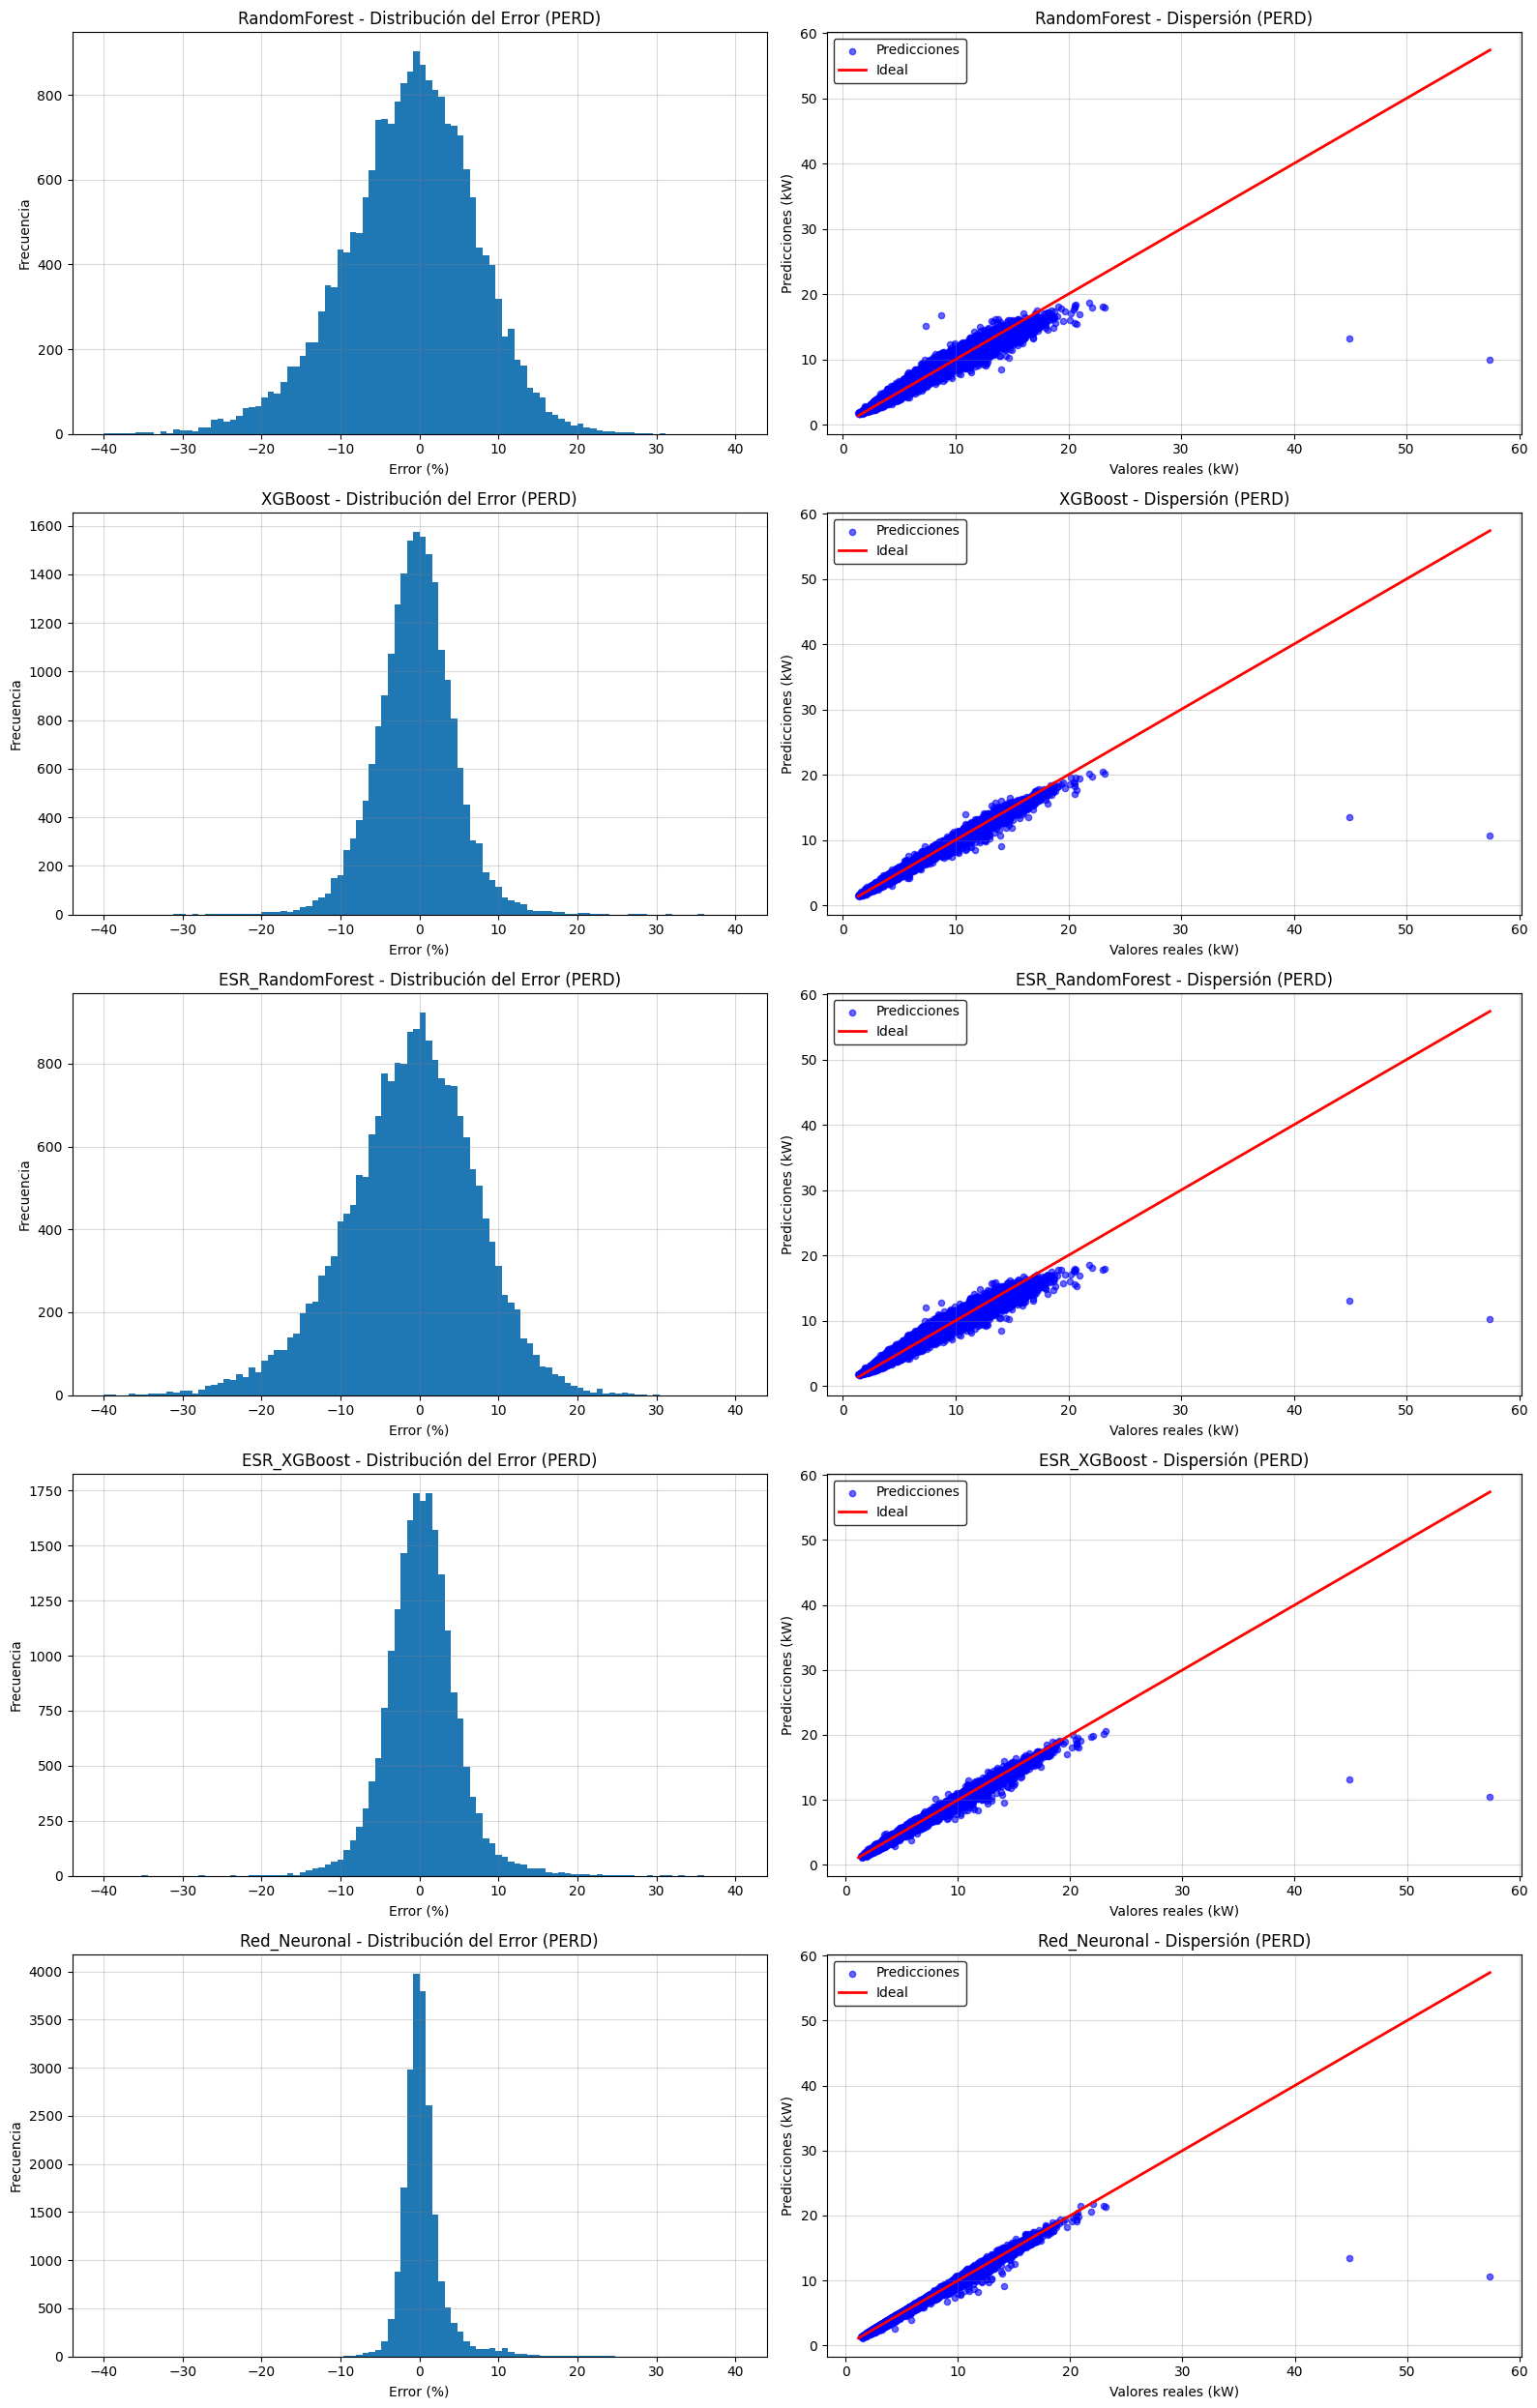

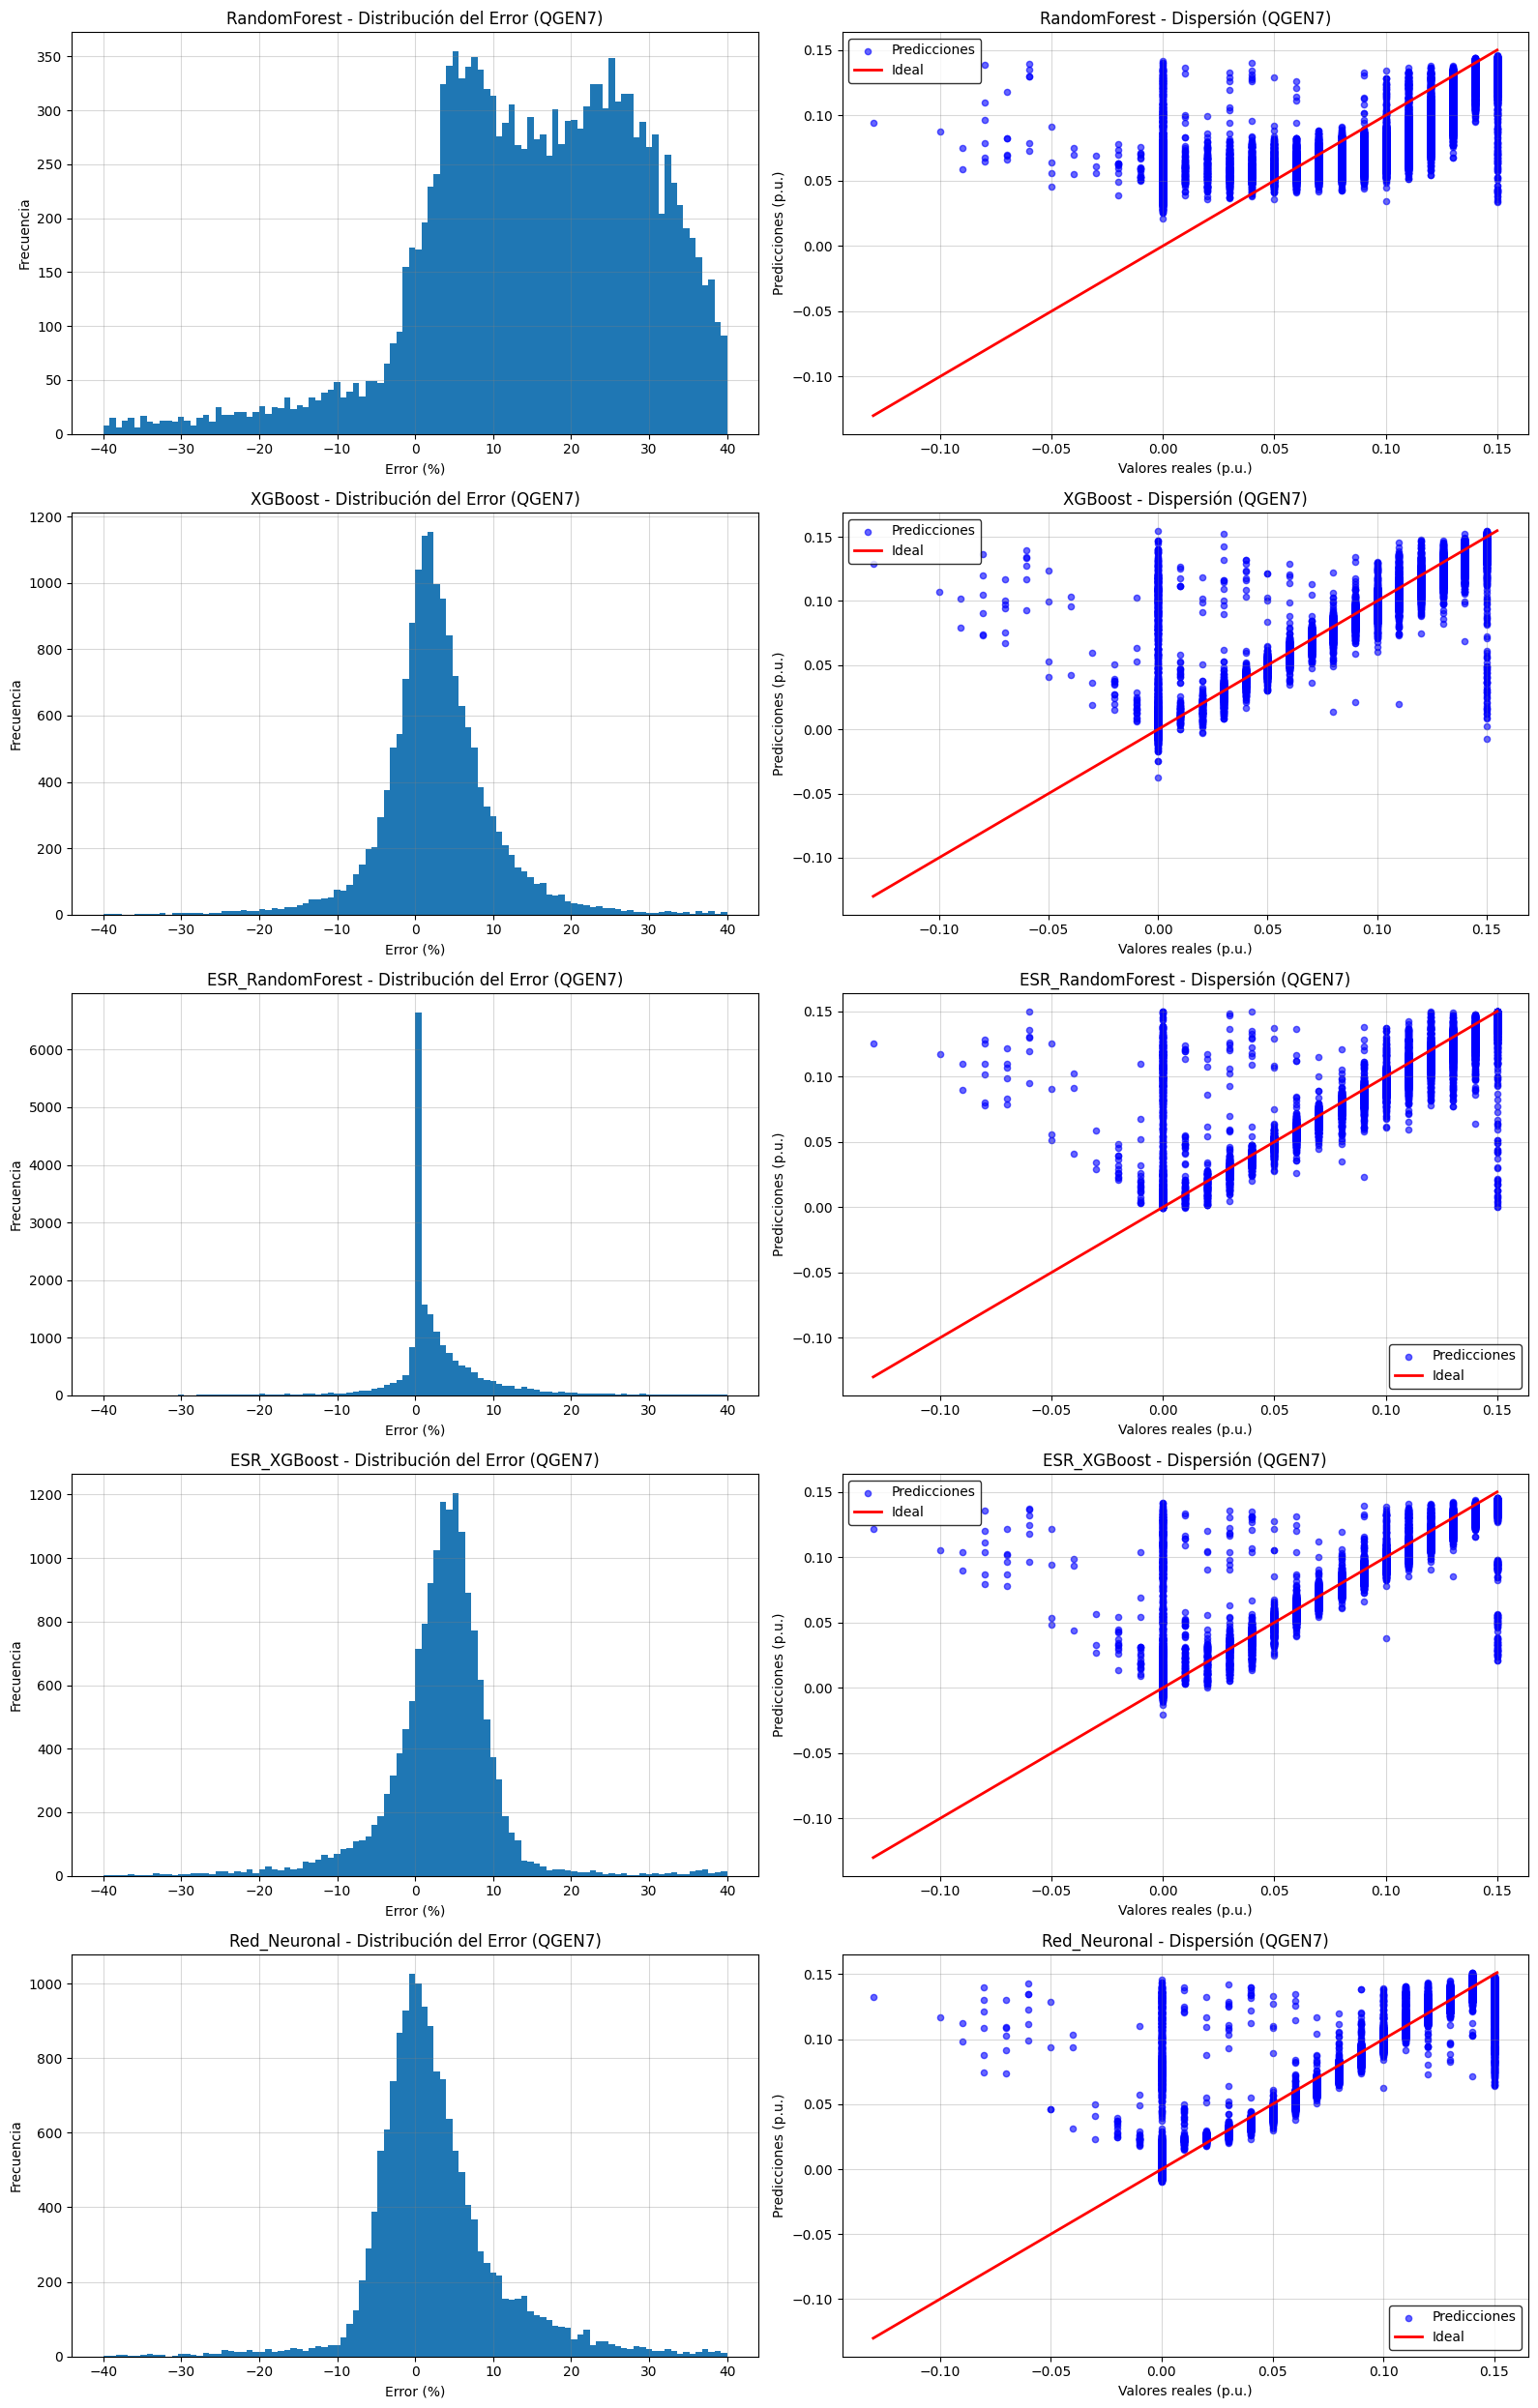

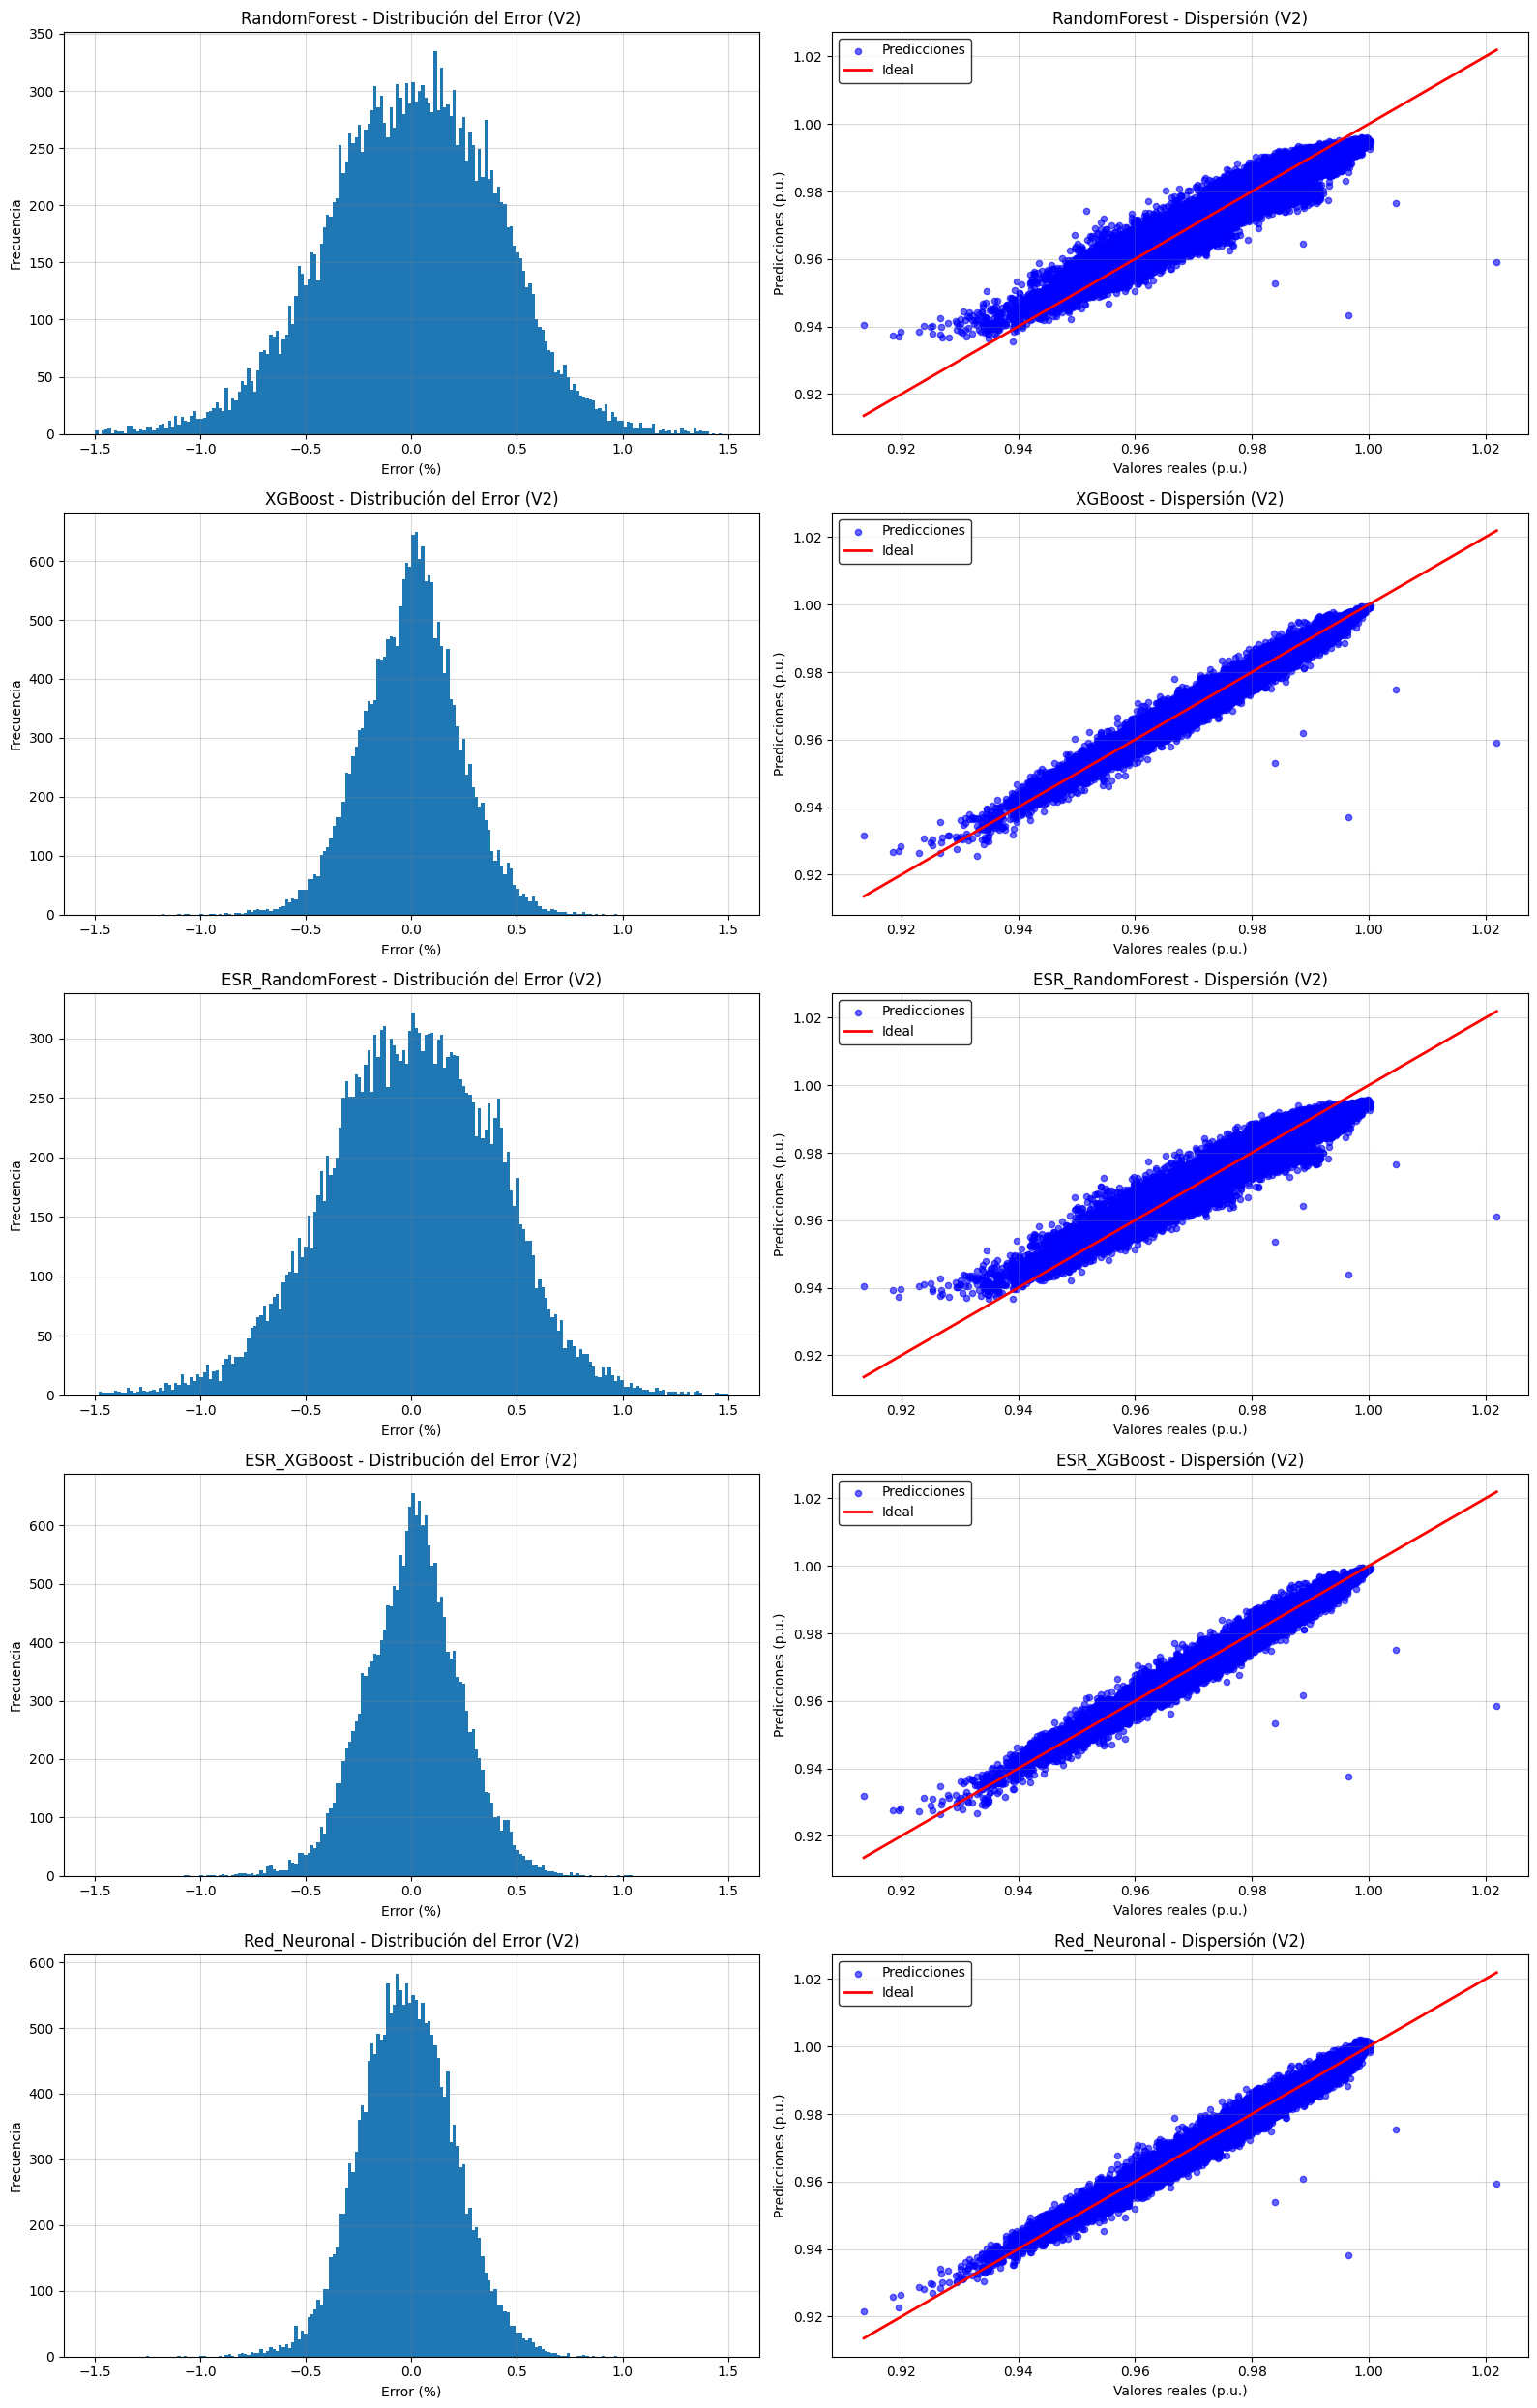

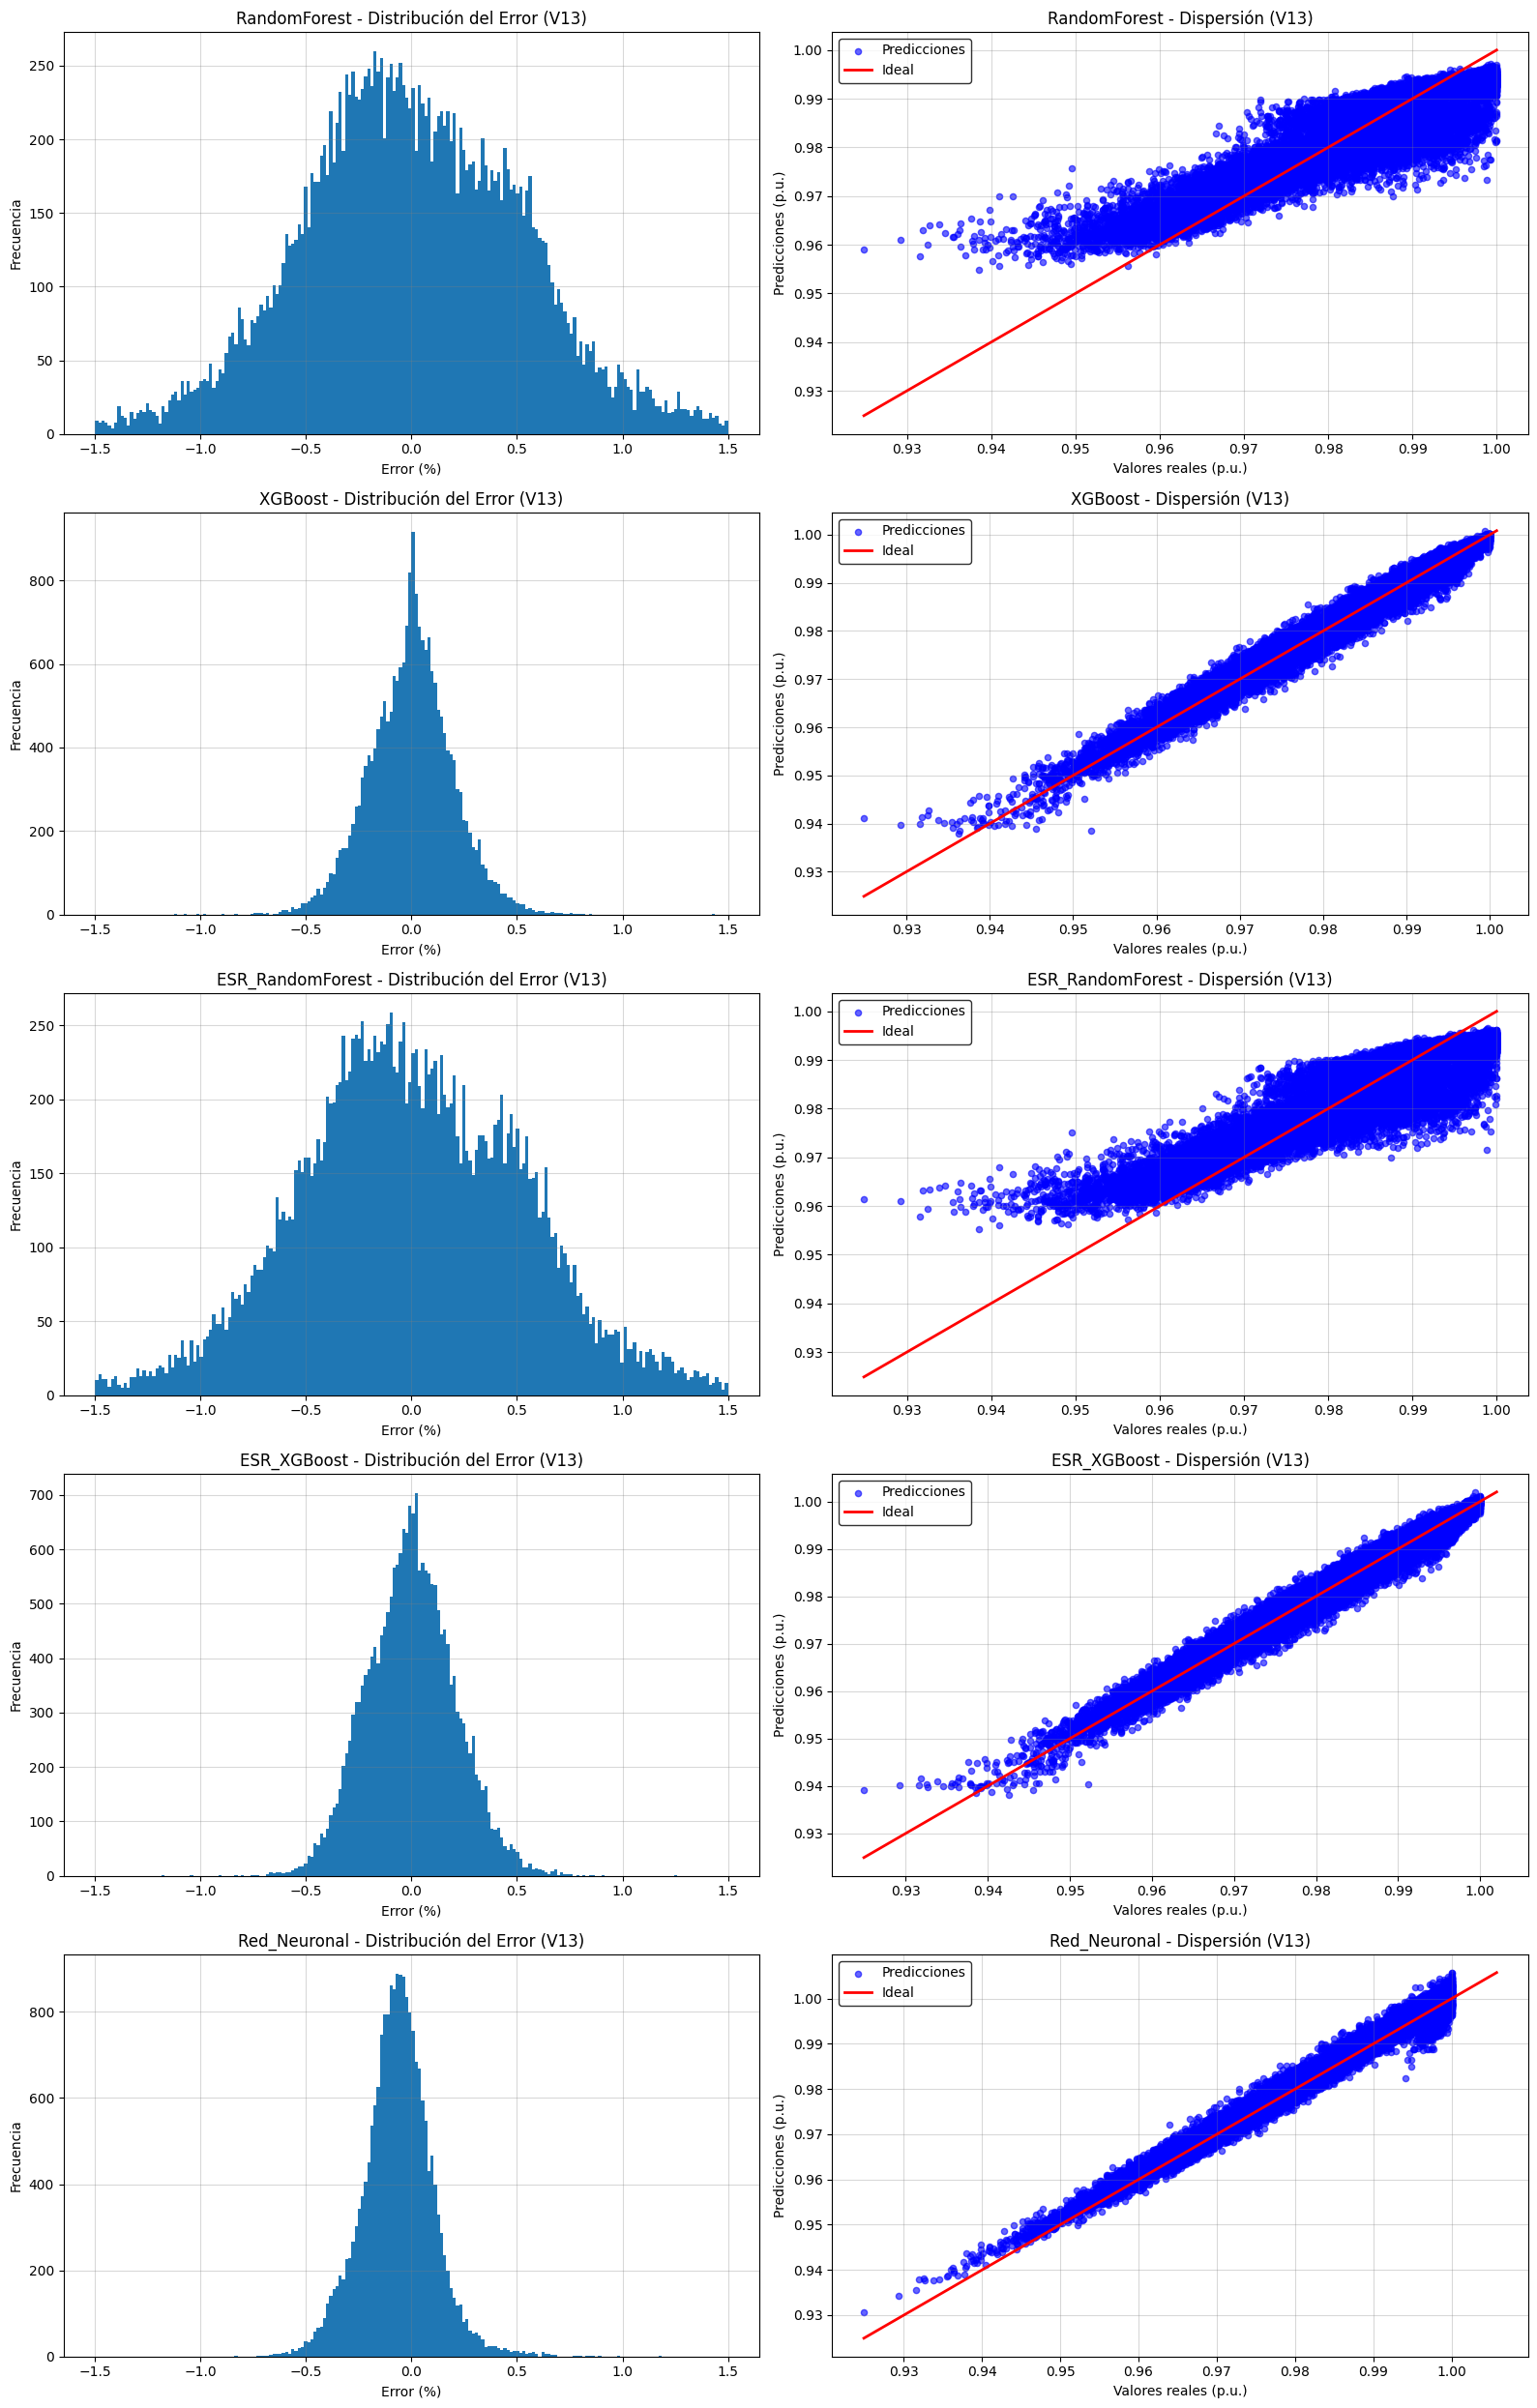

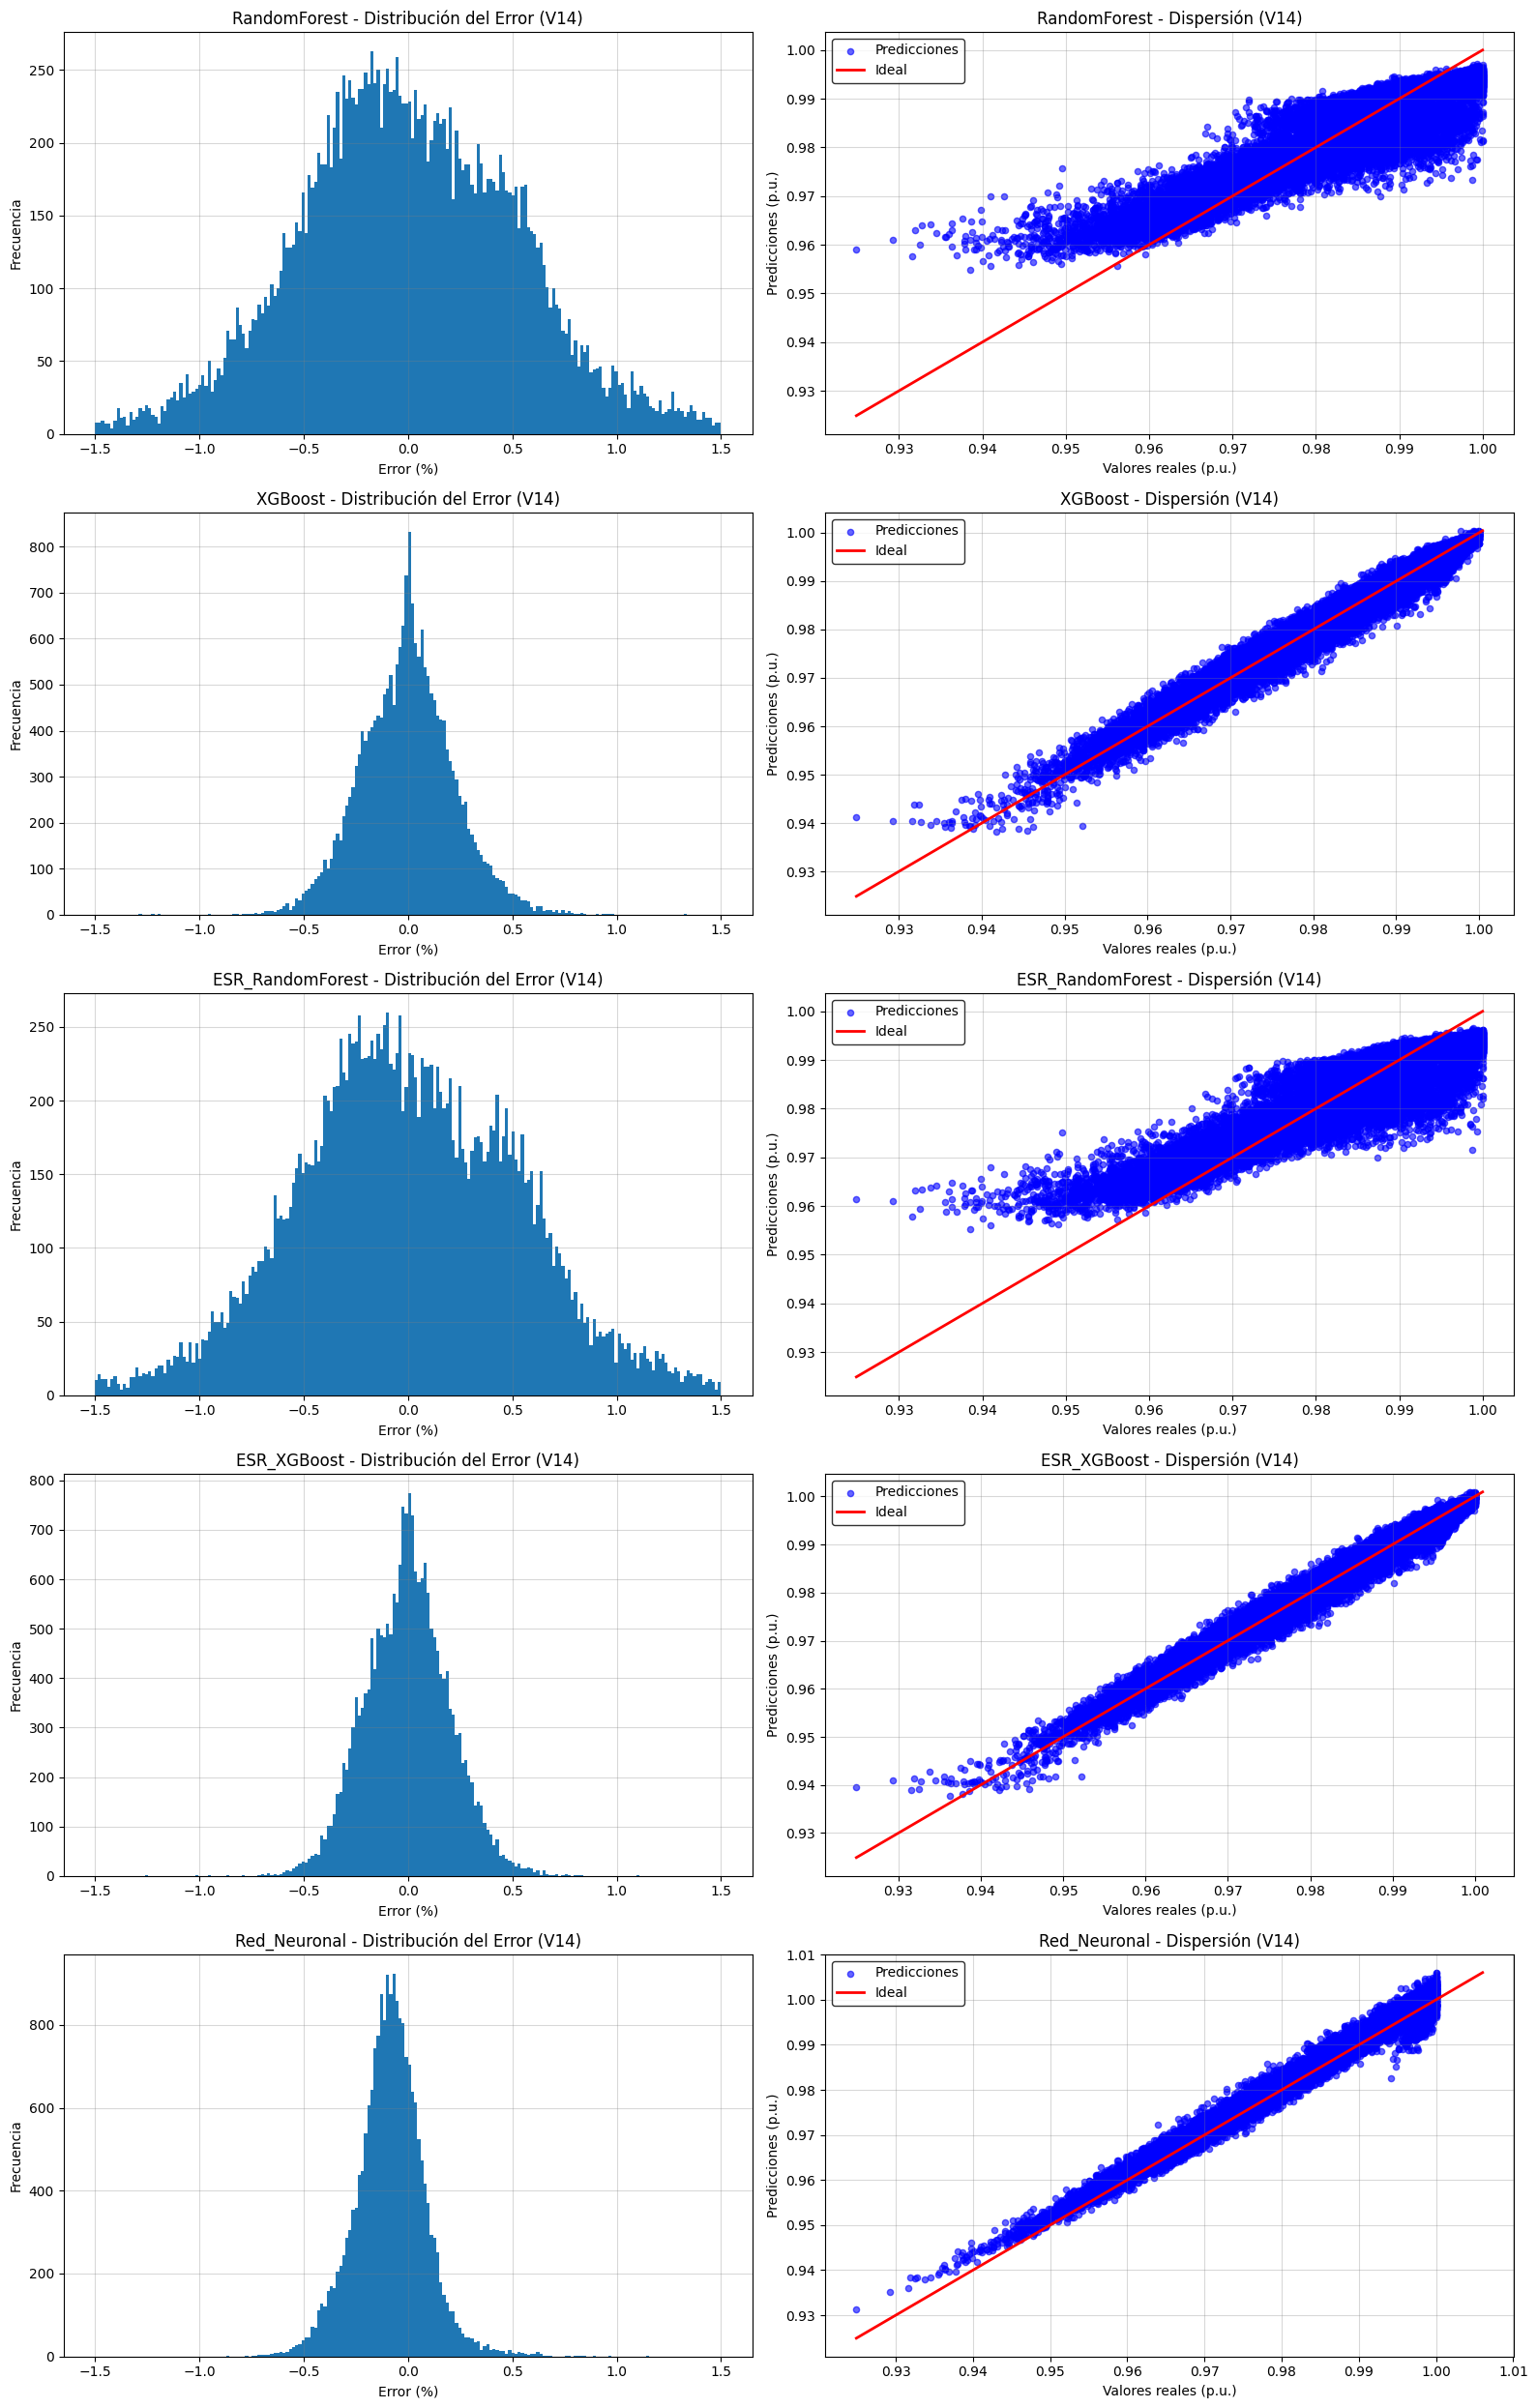

In [8]:
dict_predictions = {
    'RandomForest': rf_predictions,
    'XGBoost': xgb_predictions,
    'ESR_RandomForest': esr_rf_predictions,
    'ESR_XGBoost': esr_xgb_predictions,
    'Red_Neuronal': nn_predictions
}

variables = {
    'PERD': 'kW',
    'QGEN7': 'p.u.',
    'V2': 'p.u.',
    'V13': 'p.u.',
    'V14': 'p.u.',
}

for var_name, unit in variables.items():
    path = f'../figures/error_comparison/comparison_models_{var_name}.png'
    plot_all_models_for_variable(
        y_true_df=y_test,
        dict_preds=dict_predictions,
        variable_name=var_name,
        unit_label=unit,
        path=path
    )